In [ ]:
!pip install ultralytics opencv-python pandas openpyxl matplotlib numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
MODEL_PATH = "/content/best.pt"
IMAGE_PATH = "/content/mangrove (2).png"   #  صورة الدرون هنا
OUTPUT_DIR = Path("/content/mangrove_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

model = YOLO(MODEL_PATH)

In [ ]:
results = model.predict(
    source=IMAGE_PATH,
    imgsz=1024,
    conf=0.25,
    retina_masks=True,
    save=True
)

result = results[0]
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

h, w = image_rgb.shape[:2]
print("Image size:", w, "x", h)
print("Masks found:", 0 if result.masks is None else len(result.masks))


image 1/1 /content/mangrove (2).png: 608x1024 4 Mangrove-trees, 1006.2ms
Speed: 26.6ms preprocess, 1006.2ms inference, 91.5ms postprocess per image at shape (1, 3, 608, 1024)
Results saved to /content/runs/segment/predict
Image size: 697 x 393
Masks found: 4


In [ ]:
full_mask = np.zeros((h, w), dtype=np.uint8)

if result.masks is not None:
    masks = result.masks.data.cpu().numpy()

    for m in masks:
        # إذا الماسك مو نفس حجم الصورة، نعدله
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h))
        full_mask[m > 0.5] = 1

mask_pixels = int(full_mask.sum())
total_pixels = h * w
mask_area_percent = (mask_pixels / total_pixels) * 100

print("Mask pixels:", mask_pixels)
print("Mask Area %:", round(mask_area_percent, 2))

Mask pixels: 216147
Mask Area %: 78.91


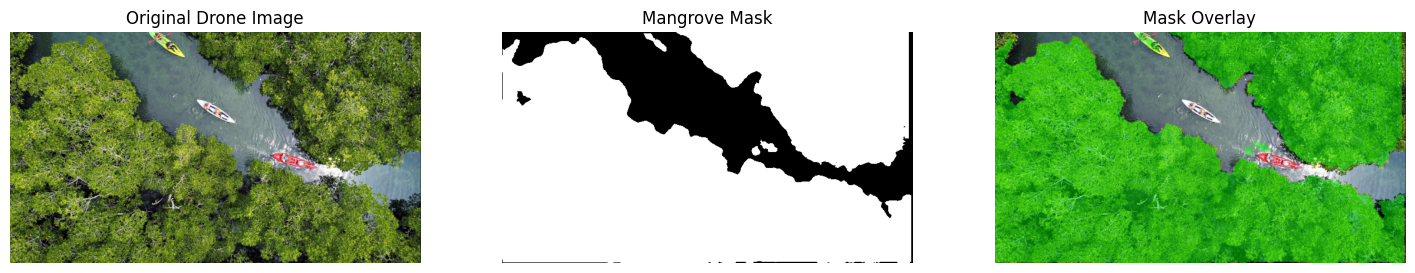

True

In [ ]:
overlay = image_rgb.copy()
green_layer = np.zeros_like(image_rgb)
green_layer[:, :, 1] = 255

alpha = 0.45
overlay = np.where(
    full_mask[..., None] == 1,
    (image_rgb * (1 - alpha) + green_layer * alpha).astype(np.uint8),
    image_rgb
)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Drone Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(full_mask, cmap="gray")
plt.title("Mangrove Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Mask Overlay")
plt.axis("off")

plt.show()

cv2.imwrite(str(OUTPUT_DIR / "mask.png"), full_mask * 255)
cv2.imwrite(str(OUTPUT_DIR / "overlay.jpg"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

In [ ]:
masked_pixels = image_rgb[full_mask == 1]

if len(masked_pixels) == 0:
    raise ValueError("No mangrove mask detected. جرّبي تخفضين conf أو استخدمي صورة أوضح.")

R = masked_pixels[:, 0].astype(np.float32)
G = masked_pixels[:, 1].astype(np.float32)
B = masked_pixels[:, 2].astype(np.float32)

# مؤشرات RGB
green_pixels = (G > R * 1.08) & (G > B * 1.08) & (G > 55)
brown_pixels = (R > 70) & (G > 45) & (B < 95) & (R > B * 1.15) & (R >= G * 0.85)
dark_pixels = (R < 55) & (G < 55) & (B < 55)

green_ratio = green_pixels.mean() * 100
brown_ratio = brown_pixels.mean() * 100
dark_ratio = dark_pixels.mean() * 100
vegetation_density = G.mean() / 255 * 100

# Excess Green Index تقريبي من RGB
exg = 2 * G - R - B
exg_norm = np.clip((exg - exg.min()) / (exg.max() - exg.min() + 1e-6), 0, 1)
exg_mean = exg_norm.mean() * 100

features = {
    "Mangrove Coverage %": round(mask_area_percent, 2),
    "Green Ratio %": round(green_ratio, 2),
    "Brown/Dry Ratio %": round(brown_ratio, 2),
    "Dark Area Ratio %": round(dark_ratio, 2),
    "Vegetation Density %": round(vegetation_density, 2),
    "Excess Green Index %": round(exg_mean, 2),
}

features

{'Mangrove Coverage %': 78.91,
 'Green Ratio %': np.float64(81.67),
 'Brown/Dry Ratio %': np.float64(13.98),
 'Dark Area Ratio %': np.float64(11.25),
 'Vegetation Density %': np.float32(42.24),
 'Excess Green Index %': np.float32(56.38)}

In [ ]:
grid_size = 5
cell_h = h // grid_size
cell_w = w // grid_size

grid_records = []

for row in range(grid_size):
    for col in range(grid_size):
        y1, y2 = row * cell_h, (row + 1) * cell_h
        x1, x2 = col * cell_w, (col + 1) * cell_w

        cell_mask = full_mask[y1:y2, x1:x2]
        coverage = cell_mask.mean() * 100

        if coverage >= 80:
            status = "Crowded"
        elif coverage <= 25:
            status = "Gap / Sparse"
        else:
            status = "Normal"

        grid_records.append({
            "Cell": f"R{row+1}C{col+1}",
            "Coverage %": round(coverage, 2),
            "Status": status
        })

grid_df = pd.DataFrame(grid_records)
display(grid_df)

gap_ratio = (grid_df["Status"] == "Gap / Sparse").mean() * 100
crowded_ratio = (grid_df["Status"] == "Crowded").mean() * 100

if crowded_ratio >= 25:
    crowding_level = "High"
elif crowded_ratio >= 10:
    crowding_level = "Medium"
else:
    crowding_level = "Low"

if gap_ratio >= 35:
    gap_level = "High"
elif gap_ratio >= 15:
    gap_level = "Medium"
else:
    gap_level = "Low"

print("Gap Ratio:", round(gap_ratio, 2), "%")
print("Crowded Ratio:", round(crowded_ratio, 2), "%")
print("Crowding Level:", crowding_level)
print("Gap Level:", gap_level)

,Cell,Coverage %,Status
0,R1C1,59.95,Normal
1,R1C2,19.36,Gap / Sparse
2,R1C3,61.34,Normal
3,R1C4,98.48,Crowded
4,R1C5,96.40,Crowded
5,R2C1,96.86,Crowded
6,R2C2,53.15,Normal
7,R2C3,4.17,Gap / Sparse
8,R2C4,80.27,Crowded
9,R2C5,96.40,Crowded


Gap Ratio: 8.0 %
Crowded Ratio: 68.0 %
Crowding Level: High
Gap Level: Low


In [ ]:
health_score = (
    0.35 * green_ratio +
    0.25 * vegetation_density +
    0.20 * exg_mean +
    0.10 * mask_area_percent
    - 0.20 * brown_ratio
    - 0.10 * dark_ratio
    - 0.10 * gap_ratio
)

health_score = float(np.clip(health_score, 0, 100))

def classify_health(score):
    if score >= 80:
        return "Healthy"
    elif score >= 60:
        return "Moderate Stress"
    elif score >= 40:
        return "High Stress"
    return "Degraded"

health_status = classify_health(health_score)

print("Health Score:", round(health_score, 2), "%")
print("Current Status:", health_status)

Health Score: 53.59 %
Current Status: High Stress


In [ ]:
EXPECTED_SEEDLINGS = 625

# تقدير بسيط: الصحة تمثل نسبة الشتلات الناجحة
estimated_healthy_seedlings = int(round(EXPECTED_SEEDLINGS * (health_score / 100)))
estimated_weak_missing = EXPECTED_SEEDLINGS - estimated_healthy_seedlings
survival_rate = (estimated_healthy_seedlings / EXPECTED_SEEDLINGS) * 100

print("Expected Seedlings:", EXPECTED_SEEDLINGS)
print("Estimated Healthy Seedlings:", estimated_healthy_seedlings)
print("Estimated Weak/Missing Seedlings:", estimated_weak_missing)
print("Survival Rate:", round(survival_rate, 2), "%")

Expected Seedlings: 625
Estimated Healthy Seedlings: 335
Estimated Weak/Missing Seedlings: 290
Survival Rate: 53.6 %


In [ ]:
survey_inputs = {
    "Monitoring Point ID": "P04",
    "Survey Date": "2026-06-11",
    "Team Name": "Blue Carbon AI",
    "Temperature °C": 42,
    "Humidity %": 35,
    "Salinity Level": "High",     # Low / Medium / High
    "Water Level": "Low",         # Low / Normal / High
    "Rainfall": "Low",            # Low / Medium / High
    "Field Notes": ""
}

survey_inputs

{'Monitoring Point ID': 'P04',
 'Survey Date': '2026-06-11',
 'Team Name': 'Blue Carbon AI',
 'Temperature °C': 42,
 'Humidity %': 35,
 'Salinity Level': 'High',
 'Water Level': 'Low',
 'Rainfall': 'Low',
 'Field Notes': ''}

In [ ]:
def risk_score_rule(health, survival, brown, gaps, crowding, salinity, water_level, temp):
    risk = 0

    # الصحة والبقاء
    risk += max(0, 100 - health) * 0.35
    risk += max(0, 100 - survival) * 0.25

    # مؤشرات الصورة
    risk += brown * 0.15
    risk += gaps * 0.15

    if crowding == "High":
        risk += 10
    elif crowding == "Medium":
        risk += 5

    # البيئة
    if salinity == "High":
        risk += 10
    elif salinity == "Medium":
        risk += 5

    if water_level == "Low":
        risk += 10

    if temp >= 40:
        risk += 8

    return float(np.clip(risk, 0, 100))

risk_score = risk_score_rule(
    health=health_score,
    survival=survival_rate,
    brown=brown_ratio,
    gaps=gap_ratio,
    crowding=crowding_level,
    salinity=survey_inputs["Salinity Level"],
    water_level=survey_inputs["Water Level"],
    temp=survey_inputs["Temperature °C"]
)

def classify_risk(score):
    if score >= 75:
        return "Critical"
    elif score >= 55:
        return "High"
    elif score >= 35:
        return "Medium"
    return "Low"

risk_level = classify_risk(risk_score)

print("Risk Score:", round(risk_score, 2), "%")
print("Risk Level:", risk_level)

Risk Score: 69.14 %
Risk Level: High


In [ ]:
def priority_from_risk(risk_level):
    mapping = {
        "Critical": "Immediate Field Visit",
        "High": "Inspect Within 7 Days",
        "Medium": "Monitor Next Round",
        "Low": "Stable"
    }
    return mapping[risk_level]

priority = priority_from_risk(risk_level)
print("Priority:", priority)

Priority: Inspect Within 7 Days


In [ ]:
auto_survey = {
    **survey_inputs,
    "Expected Seedlings": EXPECTED_SEEDLINGS,
    "Estimated Healthy Seedlings": estimated_healthy_seedlings,
    "Estimated Weak/Missing Seedlings": estimated_weak_missing,
    "Survival Rate %": round(survival_rate, 2),
    "Health Score %": round(health_score, 2),
    "Current Status": health_status,
    "Mangrove Coverage %": round(mask_area_percent, 2),
    "Green Ratio %": round(green_ratio, 2),
    "Brown/Dry Ratio %": round(brown_ratio, 2),
    "Vegetation Density %": round(vegetation_density, 2),
    "Gap Ratio %": round(gap_ratio, 2),
    "Crowding Level": crowding_level,
    "Gap Level": gap_level,
    "Risk Score %": round(risk_score, 2),
    "Risk Level": risk_level,
    "Priority": priority,
    "AI Generated": True
}

survey_df = pd.DataFrame([auto_survey])
display(survey_df)

,Monitoring Point ID,Survey Date,Team Name,Temperature °C,Humidity %,Salinity Level,Water Level,Rainfall,Field Notes,Expected Seedlings,...,Green Ratio %,Brown/Dry Ratio %,Vegetation Density %,Gap Ratio %,Crowding Level,Gap Level,Risk Score %,Risk Level,Priority,AI Generated
0,P04,2026-06-11,Blue Carbon AI,42,35,High,Low,Low,,625,...,81.67,13.98,42.240002,8.0,High,Low,69.14,High,Inspect Within 7 Days,True


In [ ]:
def generate_agent_report(s):
    return f"""
Environmental AI Agent Report

Monitoring Point: {s['Monitoring Point ID']}
Survey Date: {s['Survey Date']}

Summary:
The monitoring point has a Health Score of {s['Health Score %']}% and a Survival Rate of {s['Survival Rate %']}%.
The current status is classified as {s['Current Status']}, with a {s['Risk Level']} risk level.

Key Findings:
- Mangrove coverage: {s['Mangrove Coverage %']}%
- Green vegetation ratio: {s['Green Ratio %']}%
- Brown/dry ratio: {s['Brown/Dry Ratio %']}%
- Gap ratio: {s['Gap Ratio %']}%
- Crowding level: {s['Crowding Level']}

Recommended Action:
{s['Priority']}

Reason:
The recommendation is based on the health score, survival rate, vegetation coverage, gap areas, and environmental conditions such as salinity and water level.
"""

agent_report = generate_agent_report(auto_survey)
print(agent_report)


Environmental AI Agent Report

Monitoring Point: P04
Survey Date: 2026-06-11

Summary:
The monitoring point has a Health Score of 53.59% and a Survival Rate of 53.6%.
The current status is classified as High Stress, with a High risk level.

Key Findings:
- Mangrove coverage: 78.91%
- Green vegetation ratio: 81.67%
- Brown/dry ratio: 13.98%
- Gap ratio: 8.0%
- Crowding level: High

Recommended Action:
Inspect Within 7 Days

Reason:
The recommendation is based on the health score, survival rate, vegetation coverage, gap areas, and environmental conditions such as salinity and water level.



In [ ]:
excel_path = OUTPUT_DIR / "auto_filled_mangrove_survey.xlsx"
report_path = OUTPUT_DIR / "agent_report.txt"

survey_df.to_excel(excel_path, index=False)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(agent_report)

print("Saved:", excel_path)
print("Saved:", report_path)
print("Saved overlay:", OUTPUT_DIR / "overlay.jpg")
print("Saved mask:", OUTPUT_DIR / "mask.png")

Saved: /content/mangrove_outputs/auto_filled_mangrove_survey.xlsx
Saved: /content/mangrove_outputs/agent_report.txt
Saved overlay: /content/mangrove_outputs/overlay.jpg
Saved mask: /content/mangrove_outputs/mask.png


In [ ]:
from google.colab import files

files.download(str(excel_path))
files.download(str(report_path))
files.download(str(OUTPUT_DIR / "overlay.jpg"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def analyze_image(
    image_path,
    point_id="P00",
    expected_seedlings=625,
    survey_date="2026-06-11",
    team_name="Blue Carbon AI",
    temperature=42,
    humidity=35,
    salinity="High",
    water_level="Low",
    rainfall="Low",
    field_notes=""
):
    results = model.predict(
        source=image_path,
        imgsz=1024,
        conf=0.25,
        retina_masks=True,
        verbose=False
    )

    result = results[0]

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    if result.masks is not None:
        for m in result.masks.data.cpu().numpy():
            if m.shape != (h, w):
                m = cv2.resize(m, (w, h))
            mask[m > 0.5] = 1

    base_record = {
        "Monitoring Point ID": point_id,
        "Survey Date": survey_date,
        "Team Name": team_name,
        "Temperature °C": temperature,
        "Humidity %": humidity,
        "Salinity Level": salinity,
        "Water Level": water_level,
        "Rainfall": rainfall,
        "Field Notes": field_notes,
        "Expected Seedlings": expected_seedlings,
    }

    if mask.sum() == 0:
        return {
            **base_record,
            "Estimated Healthy Seedlings": 0,
            "Estimated Weak/Missing Seedlings": expected_seedlings,
            "Survival Rate %": 0,
            "Health Score %": 0,
            "Current Status": "No Mangrove Detected",
            "Mangrove Coverage %": 0,
            "Green Ratio %": 0,
            "Brown/Dry Ratio %": 0,
            "Vegetation Density %": 0,
            "Gap Ratio %": 100,
            "Crowding Level": "Low",
            "Gap Level": "High",
            "Risk Score %": 100,
            "Risk Level": "Critical",
            "Priority": "Immediate Field Visit",
            "AI Generated": True
        }

    pixels = img_rgb[mask == 1]
    R = pixels[:, 0].astype(np.float32)
    G = pixels[:, 1].astype(np.float32)
    B = pixels[:, 2].astype(np.float32)

    green_ratio = ((G > R * 1.08) & (G > B * 1.08) & (G > 55)).mean() * 100
    brown_ratio = ((R > 70) & (G > 45) & (B < 95) & (R > B * 1.15) & (R >= G * 0.85)).mean() * 100
    dark_ratio = ((R < 55) & (G < 55) & (B < 55)).mean() * 100
    vegetation_density = G.mean() / 255 * 100
    mangrove_coverage = mask.mean() * 100

    exg = 2 * G - R - B
    exg_norm = np.clip((exg - exg.min()) / (exg.max() - exg.min() + 1e-6), 0, 1)
    exg_mean = exg_norm.mean() * 100

    grid_size = 5
    cell_h = h // grid_size
    cell_w = w // grid_size

    coverages = []

    for row in range(grid_size):
        for col in range(grid_size):
            y1, y2 = row * cell_h, (row + 1) * cell_h
            x1, x2 = col * cell_w, (col + 1) * cell_w
            coverages.append(mask[y1:y2, x1:x2].mean() * 100)

    coverages = np.array(coverages)

    gap_ratio = (coverages <= 25).mean() * 100
    crowded_ratio = (coverages >= 80).mean() * 100

    crowding_level = "High" if crowded_ratio >= 25 else "Medium" if crowded_ratio >= 10 else "Low"
    gap_level = "High" if gap_ratio >= 35 else "Medium" if gap_ratio >= 15 else "Low"

    health_score = (
        0.35 * green_ratio +
        0.25 * vegetation_density +
        0.20 * exg_mean +
        0.10 * mangrove_coverage
        - 0.20 * brown_ratio
        - 0.10 * dark_ratio
        - 0.10 * gap_ratio
    )

    health_score = float(np.clip(health_score, 0, 100))
    health_status = classify_health(health_score)

    estimated_healthy = int(round(expected_seedlings * (health_score / 100)))
    estimated_weak_missing = expected_seedlings - estimated_healthy
    survival_rate = (estimated_healthy / expected_seedlings) * 100

    risk_score = risk_score_rule(
        health=health_score,
        survival=survival_rate,
        brown=brown_ratio,
        gaps=gap_ratio,
        crowding=crowding_level,
        salinity=salinity,
        water_level=water_level,
        temp=temperature
    )

    risk_level = classify_risk(risk_score)
    priority = priority_from_risk(risk_level)

    return {
        **base_record,
        "Estimated Healthy Seedlings": estimated_healthy,
        "Estimated Weak/Missing Seedlings": estimated_weak_missing,
        "Survival Rate %": round(survival_rate, 2),
        "Health Score %": round(health_score, 2),
        "Current Status": health_status,
        "Mangrove Coverage %": round(mangrove_coverage, 2),
        "Green Ratio %": round(green_ratio, 2),
        "Brown/Dry Ratio %": round(brown_ratio, 2),
        "Vegetation Density %": round(vegetation_density, 2),
        "Gap Ratio %": round(gap_ratio, 2),
        "Crowding Level": crowding_level,
        "Gap Level": gap_level,
        "Risk Score %": round(risk_score, 2),
        "Risk Level": risk_level,
        "Priority": priority,
        "AI Generated": True
    }

In [ ]:
from pathlib import Path
from google.colab import files

image_folder = "/content/images_folder"  # عدلي مسار مجلد الصور
image_paths = (
    list(Path(image_folder).glob("*.jpg")) +
    list(Path(image_folder).glob("*.jpeg")) +
    list(Path(image_folder).glob("*.png"))
)

records = []

for idx, img_path in enumerate(image_paths, start=1):
    records.append(
        analyze_image(
            image_path=str(img_path),
            point_id=f"P{idx:02d}",
            expected_seedlings=625,
            survey_date="2026-06-11",
            team_name="Blue Carbon AI",
            temperature=42,
            humidity=35,
            salinity="High",
            water_level="Low",
            rainfall="Low"
        )
    )

all_surveys_df = pd.DataFrame(records)

# ترتيب حسب الخطر عشان يطلع ملف الأولويات جاهز
all_surveys_df = all_surveys_df.sort_values(
    by="Risk Score %",
    ascending=False
)

display(all_surveys_df)

excel_path = OUTPUT_DIR / "all_monitoring_surveys_full.xlsx"
all_surveys_df.to_excel(excel_path, index=False)

files.download(str(excel_path))

,Monitoring Point ID,Survey Date,Team Name,Temperature °C,Humidity %,Salinity Level,Water Level,Rainfall,Field Notes,Expected Seedlings,...,Green Ratio %,Brown/Dry Ratio %,Vegetation Density %,Gap Ratio %,Crowding Level,Gap Level,Risk Score %,Risk Level,Priority,AI Generated
2,P03,2026-06-11,Blue Carbon AI,42,35,High,Low,Low,,625,...,8.29,55.23,36.279999,0.0,High,Low,96.47,Critical,Immediate Field Visit,True
1,P02,2026-06-11,Blue Carbon AI,42,35,High,Low,Low,,625,...,44.66,45.61,34.570000,12.0,High,Low,88.03,Critical,Immediate Field Visit,True
0,P01,2026-06-11,Blue Carbon AI,42,35,High,Low,Low,,625,...,91.38,4.84,42.730000,32.0,High,Medium,70.13,High,Inspect Within 7 Days,True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

excel_file = OUTPUT_DIR / "all_monitoring_surveys.xlsx"

files.download(str(excel_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>